<center><h1>Assignment # 01

<h3>Problem 01: “Employee Performance and Salary Analysis”

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
num_people = 500
data = {
    'ID': np.arange(1, num_people + 1),
    'Name': [f"Person {i}" for i in range(1, num_people + 1)],
    'Age': np.random.randint(22, 60, size=num_people),
    'Gender': np.random.choice(['Male', 'Female'], size=num_people),
    'Department': np.random.choice(['Sales', 'HR', 'Finance', 'IT', 'Marketing'], size=num_people),
    'Salary': np.random.randint(40000, 60000, size=num_people),
    'YearsInCompany': np.random.randint(1, 30, size=num_people),
    'PerformanceScore': np.random.randint(1, 5, size=num_people),
}
df = pd.DataFrame(data)
df['PromotionEligibility'] = np.where(df['PerformanceScore'].isin([4, 5]), 'Yes', 'No')
print(df.head(10))


   ID       Name  Age  Gender Department  Salary  YearsInCompany  \
0   1   Person 1   52    Male         HR   59097              27   
1   2   Person 2   47    Male  Marketing   52320               9   
2   3   Person 3   39  Female         IT   46499               9   
3   4   Person 4   44    Male  Marketing   55270              13   
4   5   Person 5   45    Male    Finance   56167              20   
5   6   Person 6   27    Male         HR   51604              12   
6   7   Person 7   57    Male    Finance   57629              24   
7   8   Person 8   31  Female         IT   59342              18   
8   9   Person 9   53    Male  Marketing   47195              21   
9  10  Person 10   25  Female    Finance   40330              21   

   PerformanceScore PromotionEligibility  
0                 3                   No  
1                 3                   No  
2                 3                   No  
3                 4                  Yes  
4                 3                 

<h3>Part (B): Data Cleaning and Transformation

In [37]:
num_missing = int(0.1 * len(df))  
random_indice = np.random.choice(df.index, size=num_missing, replace=False)
df.loc[random_indice, 'Salary'] = np.nan
print(df['Salary'].head(10))
print("Total null values " ,df['Salary'].isnull().sum())

0    59097.0
1        NaN
2    46499.0
3    55270.0
4    56167.0
5    51604.0
6        NaN
7    59342.0
8    47195.0
9        NaN
Name: Salary, dtype: float64
Total null values  261


In [8]:
num_invalid = int(0.05 * len(df))
invalid_score = np.random.choice([-1, 6], size=num_invalid)
random_indice = np.random.choice(df.index, size=num_invalid, replace=False)
df.loc[random_indice, 'PerformanceScore'] = invalid_score
print(df['PerformanceScore'].head(10))

0    3
1    3
2    3
3    6
4    3
5   -1
6    4
7    1
8    2
9    4
Name: PerformanceScore, dtype: int64


C:\Users\M.Hafeez\AppData\Local\Temp\ipykernel_14632\1137841406.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1 -1 -1  6 -1 -1  6 -1 -1  6  6 -1 -1 -1  6 -1 -1 -1  6  6 -1 -1  6  6
  6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[random_indice, 'PerformanceScore'] = invalid_score


In [44]:
df['Salary'].fillna(df['Salary'].median())
print(df.head())
print("Total null values:", df['Salary'].isnull().sum())


   ID      Name  Age  Gender Department   Salary  YearsInCompany  \
0   1  Person 1   52    Male         HR  59097.0              27   
1   2  Person 2   47    Male  Marketing  50383.0               9   
2   3  Person 3   39  Female         IT  46499.0               9   
3   4  Person 4   44    Male  Marketing  55270.0              13   
4   5  Person 5   45    Male    Finance  56167.0              20   

   PerformanceScore PromotionEligibility  
0                 3                   No  
1                 3                   No  
2                 3                   No  
3                 6                  Yes  
4                 3                   No  
Total null values: 0


In [24]:
#Filter out employees with invalid Performance Score values (outside the range of 1 to 5).
invalid_scores_df = df[(df['PerformanceScore'] < 1) | (df['PerformanceScore'] > 5)]
print(invalid_scores_df.head(10))


      ID        Name  Age  Gender Department   Salary  YearsInCompany  \
3      4    Person 4   44    Male  Marketing  55270.0              13   
5      6    Person 6   27    Male         HR  51604.0              12   
84    85   Person 85   46    Male    Finance      NaN              15   
111  112  Person 112   37  Female      Sales  51838.0              16   
117  118  Person 118   37  Female         HR  59984.0               6   
120  121  Person 121   56    Male    Finance  45017.0              23   
122  123  Person 123   48    Male      Sales  47095.0               5   
167  168  Person 168   49    Male         IT  55118.0              16   
174  175  Person 175   43    Male      Sales  43793.0              20   
181  182  Person 182   33  Female    Finance  53300.0              21   

     PerformanceScore PromotionEligibility  
3                   6                  Yes  
5                  -1                   No  
84                  6                   No  
111             

<h3>Part (C): Department-Wise Salary Analysis

In [30]:
avg_salary_by_dept = df.groupby('Department')['Salary'].mean()
print('The average Salary ($) in each department :',avg_salary_by_dept)
emp_avg_salary_by_dept = df.groupby('Department').size()
print('The Employees  in each department :', emp_avg_salary_by_dept)


The average Salary ($) in each department : Department
Finance      50906.821429
HR           48579.344828
IT           50920.866667
Marketing    50242.346154
Sales        50208.463768
Name: Salary, dtype: float64
The Employees  in each department : Department
Finance       93
HR            95
IT            94
Marketing     96
Sales        122
dtype: int64


In [32]:
highest_avg_salary_dept = avg_salary_by_dept.idxmax()
print("The department with the highest average salary is: ", highest_avg_salary_dept)

The department with the highest average salary is:  IT


In [45]:
eligible_avg_salary = df[df['PromotionEligibility']== 'Yes']['Salary'].mean()
print("The average salary of employees who are Eligible for promotion  ", eligible_avg_salary)
noneligible_avg_salary = df[df['PromotionEligibility']== 'No']['Salary'].mean()
print("The average salary of employees who are Non-eligible for promotion  ", noneligible_avg_salary)

The average salary of employees who are Eligible for promotion   50158.729508196724
The average salary of employees who are Non-eligible for promotion   50439.18783068783


C:\Users\M.Hafeez\AppData\Local\Temp\ipykernel_14632\1240503986.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([eligible_salaries, not_eligible_salaries], labels=['Eligible', 'Not Eligible'])


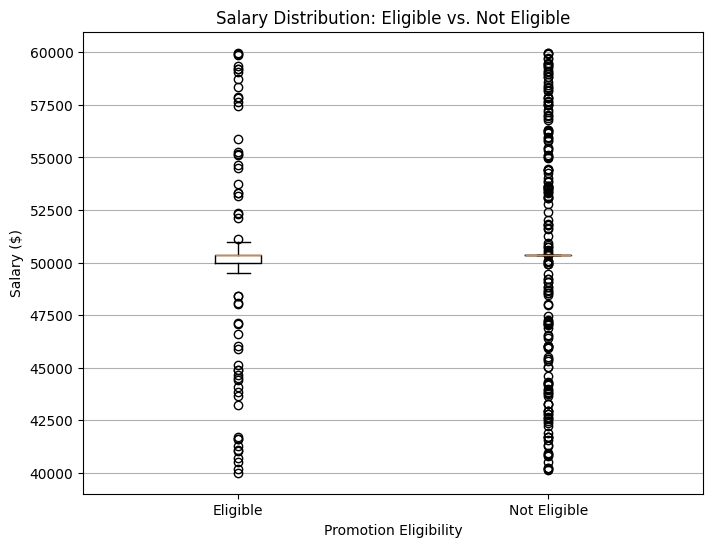

In [50]:

eligible_salaries = df[df['PromotionEligibility'] == 'Yes']['Salary']
not_eligible_salaries = df[df['PromotionEligibility'] == 'No']['Salary']
plt.figure(figsize=(8, 6))
plt.boxplot([eligible_salaries, not_eligible_salaries], labels=['Eligible', 'Not Eligible'])
plt.title("Salary Distribution: Eligible vs. Not Eligible")
plt.xlabel("Promotion Eligibility")
plt.ylabel("Salary ($)")
plt.grid(axis='y')
plt.show()
